Fetching historical weather data from Open-Meteo...
Calculating solar geometry and PV generation...
Simulating Pi 5 power draw and battery charge state...


C:\Users\jonathand\AppData\Local\Temp\ipykernel_14896\118968747.py:88: pvlibDeprecationWarning: Parameter 'g_poa_effective' has been renamed since 0.13.0. and will be removed soon. Please use 'effective_irradiance' instead.
  df['pv_power'] = pvlib.pvsystem.pvwatts_dc(



     MONTHLY SYSTEM PERFORMANCE STATISTICS
JANUARY:
  Sufficient Power (No Shutdowns) : 32 days
  Early Shutdowns                 : 0 days
  Hit 100% Charge (Excess)        : 32 days
  Mean Daily Solar Generation     : 259 Wh
--------------------------------------------------
FEBRUARY:
  Sufficient Power (No Shutdowns) : 28 days
  Early Shutdowns                 : 0 days
  Hit 100% Charge (Excess)        : 28 days
  Mean Daily Solar Generation     : 260 Wh
--------------------------------------------------
MARCH:
  Sufficient Power (No Shutdowns) : 31 days
  Early Shutdowns                 : 0 days
  Hit 100% Charge (Excess)        : 31 days
  Mean Daily Solar Generation     : 202 Wh
--------------------------------------------------
APRIL:
  Sufficient Power (No Shutdowns) : 30 days
  Early Shutdowns                 : 0 days
  Hit 100% Charge (Excess)        : 24 days
  Mean Daily Solar Generation     : 128 Wh
--------------------------------------------------
MAY:
  Sufficient Power

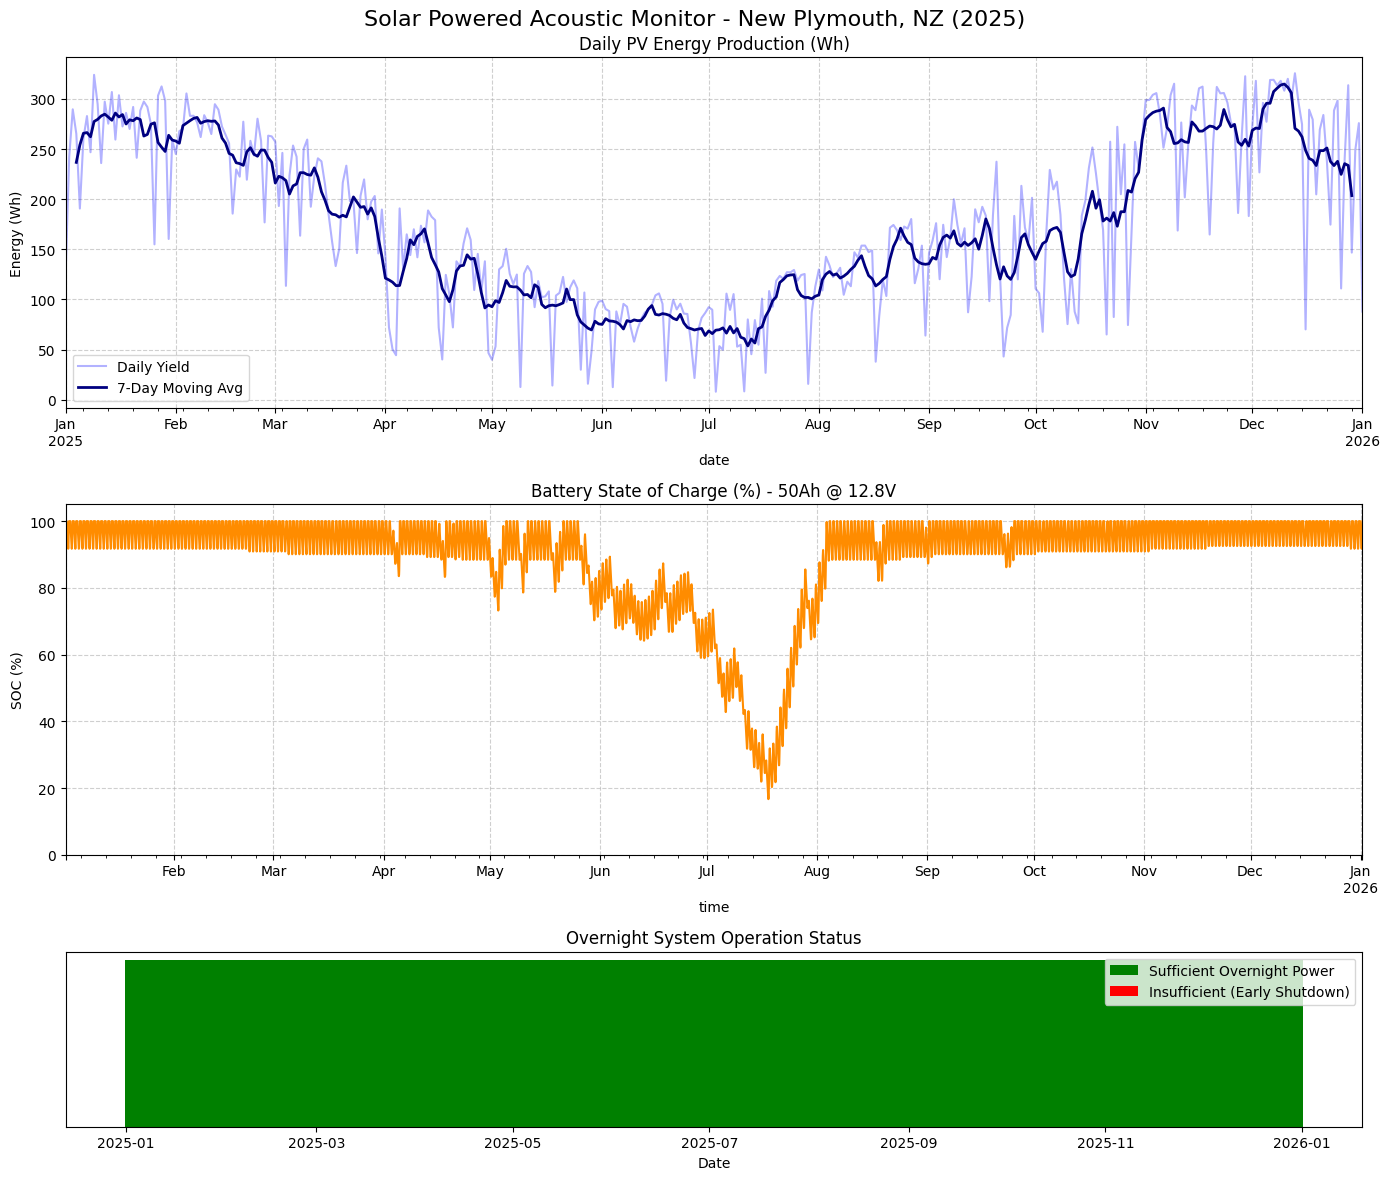

In [2]:
import requests
import pandas as pd
import numpy as np
import pvlib
from pvlib.location import Location
import matplotlib.pyplot as plt
import datetime

# ==========================================
# SYSTEM CONFIGURATION & USER INPUTS
# ==========================================

# Load Profile Percentages (Must sum to 1.0)
IDLE_PCT = 0.50      # 3.5W
MODERATE_PCT = 0.40  # 6.0W
HEAVY_PCT = 0.10     # 11.5W

# Hardware Specifications
PANEL_WATTAGE = 50   # Watts
BATTERY_AH = 50      # Amp-hours
BATTERY_VOLTAGE = 12.8 # Volts (Change to 3.2 if using a single-cell LiFePO4 block)
SYSTEM_LOSS = 0.90   # 10% loss for MPPT and DC-DC conversion

# Location & Orientation: New Plymouth, New Zealand
LATITUDE = -39.0556
LONGITUDE = 174.0752
TILT = 35
AZIMUTH = 0  # 0° is True North in pvlib
TIMEZONE = 'Pacific/Auckland'

# Timeframe (Previous Year)
START_DATE = "2025-01-01"
END_DATE = "2025-12-31"

# ==========================================
# 1. FETCH HISTORICAL WEATHER DATA
# ==========================================
print("Fetching historical weather data from Open-Meteo...")
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ["shortwave_radiation", "direct_radiation", "diffuse_radiation", "temperature_2m", "wind_speed_10m"],
    "timezone": "UTC" # Fetch in UTC to prevent Daylight Saving Time gaps
}

response = requests.get(url, params=params)
response.raise_for_status()
data = response.json()

# Process into DataFrame
df = pd.DataFrame(data['hourly'])
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

# Convert from UTC to New Zealand local time
df.index = df.index.tz_localize('UTC').tz_convert(TIMEZONE)

# ==========================================
# 2. PV GENERATION MODELING (pvlib)
# ==========================================
print("Calculating solar geometry and PV generation...")
loc = Location(LATITUDE, LONGITUDE, tz=TIMEZONE)
solpos = loc.get_solarposition(df.index)

# Calculate total irradiance on the tilted 35° North-facing panel
tilt_irrad = pvlib.irradiance.get_total_irradiance(
    surface_tilt=TILT,
    surface_azimuth=AZIMUTH,
    dni=df['direct_radiation'],
    ghi=df['shortwave_radiation'],
    dhi=df['diffuse_radiation'],
    solar_zenith=solpos['apparent_zenith'],
    solar_azimuth=solpos['azimuth']
)

# Estimate cell temperature
temp_cell = pvlib.temperature.pvsyst_cell(
    poa_global=tilt_irrad['poa_global'],
    temp_air=df['temperature_2m'],
    wind_speed=df['wind_speed_10m']
)

# Generate PVWatts DC output
# gamma_pdc is the temperature coefficient (average mono/poly is approx -0.4%/°C)
df['pv_power'] = pvlib.pvsystem.pvwatts_dc(
    g_poa_effective=tilt_irrad['poa_global'],
    temp_cell=temp_cell,
    pdc0=PANEL_WATTAGE,
    gamma_pdc=-0.004
).fillna(0)

# ==========================================
# 3. BATTERY & LOAD SIMULATION
# ==========================================
print("Simulating Pi 5 power draw and battery charge state...")
battery_capacity_wh = BATTERY_AH * BATTERY_VOLTAGE
load_watts = (IDLE_PCT * 3.5) + (MODERATE_PCT * 6.0) + (HEAVY_PCT * 11.5)

# A solar zenith angle >= 90 indicates the sun is below the horizon (night)
df['is_night'] = solpos['apparent_zenith'] >= 90

soc_wh_array = np.zeros(len(df))
current_soc = battery_capacity_wh # Assume we start with a full battery

for i in range(len(df)):
    if df['is_night'].iloc[i]:
        # Nighttime: System is ON, draining battery
        current_soc -= load_watts
    else:
        # Daytime: System is OFF, charging battery via solar
        current_soc += (df['pv_power'].iloc[i] * SYSTEM_LOSS)
    
    # Enforce battery limits
    if current_soc > battery_capacity_wh:
        current_soc = battery_capacity_wh
    elif current_soc < 0:
        current_soc = 0
        
    soc_wh_array[i] = current_soc

df['soc_wh'] = soc_wh_array
df['soc_pct'] = (df['soc_wh'] / battery_capacity_wh) * 100

# ==========================================
# 4. DAILY & MONTHLY STATS AGGREGATION
# ==========================================
df['date'] = df.index.date
df['failed'] = df['soc_wh'] <= 0

# Group data by calendar day
daily_stats = df.groupby('date').agg(
    failed=('failed', 'any'),                  # Did the battery die during this 24hr period?
    pv_produced=('pv_power', 'sum')            # Total Wh produced
)

# Excess day = battery reached 100% capacity at least once that day
daily_excess = df.groupby('date').apply(lambda x: (x['soc_wh'] >= battery_capacity_wh).any(), include_groups=False)
daily_stats['excess'] = daily_excess

daily_stats.index = pd.to_datetime(daily_stats.index)
daily_stats['month'] = daily_stats.index.month

# Generate Monthly Text Report
print("\n" + "="*50)
print("     MONTHLY SYSTEM PERFORMANCE STATISTICS")
print("="*50)

monthly_summary = daily_stats.groupby('month').agg(
    total_days=('failed', 'count'),
    failed_days=('failed', 'sum'),
    excess_days=('excess', 'sum'),
    avg_daily_generation=('pv_produced', 'mean')
)

for month, row in monthly_summary.iterrows():
    success_days = int(row['total_days'] - row['failed_days'])
    month_name = datetime.date(2025, month, 1).strftime('%B')
    print(f"{month_name.upper()}:")
    print(f"  Sufficient Power (No Shutdowns) : {success_days} days")
    print(f"  Early Shutdowns                 : {int(row['failed_days'])} days")
    print(f"  Hit 100% Charge (Excess)        : {int(row['excess_days'])} days")
    print(f"  Mean Daily Solar Generation     : {row['avg_daily_generation']:.0f} Wh")
    print("-" * 50)

# ==========================================
# 5. MATPLOTLIB VISUALIZATION
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 2, 1]})
fig.suptitle(f'Solar Powered Acoustic Monitor - New Plymouth, NZ ({START_DATE[:4]})', fontsize=16)

# Row 1: Mean Daily Production (Smoothed with a 7-day rolling average to look cleaner)
daily_stats['pv_produced'].plot(ax=axes[0], alpha=0.3, color='blue', label='Daily Yield')
daily_stats['pv_produced'].rolling(window=7, center=True).mean().plot(ax=axes[0], color='navy', linewidth=2, label='7-Day Moving Avg')
axes[0].set_title('Daily PV Energy Production (Wh)')
axes[0].set_ylabel('Energy (Wh)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Row 2: Battery State of Charge
df['soc_pct'].plot(ax=axes[1], color='darkorange')
axes[1].set_title(f'Battery State of Charge (%) - {BATTERY_AH}Ah @ {BATTERY_VOLTAGE}V')
axes[1].set_ylabel('SOC (%)')
axes[1].set_ylim(0, 105)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Row 3: Bar plot for Success/Failure Operations
colors = ['red' if fail else 'green' for fail in daily_stats['failed']]
axes[2].bar(daily_stats.index, 1, color=colors, width=1.0)
axes[2].set_title('Overnight System Operation Status')
axes[2].set_yticks([]) # Hide Y axis ticks
axes[2].set_xlabel('Date')

# Custom legend for the bar plot
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Sufficient Overnight Power'),
                   Patch(facecolor='red', label='Insufficient (Early Shutdown)')]
axes[2].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()